<a href="https://colab.research.google.com/github/Achmad96/anomaly-fraud-detection/blob/master/fraud_detection_on_transactions_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade tensorflow==2.19.0

In [ ]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.6 MB/s eta 0:00:00


In [ ]:
!pip install torch torch-geometric scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.4 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


# Variables Initialization

In [1]:
from google.colab import drive
from pathlib import Path

drive_path = Path('/content/drive')
drive.mount(str(drive_path))
drive_path /= 'MyDrive'

Mounted at /content/drive


In [2]:
SEED = 42
THRESHOLD = 0.5
DATASET_ROOT = drive_path / 'datasets' /'fraud_dataset'
MODEL_PATH = DATASET_ROOT / 'fraud_detection_model.keras'
SCALER_PATH = DATASET_ROOT / 'fraud_scaler.pkl'
MODEL_CHECKPOINT = DATASET_ROOT / 'fraud_detection_model_checkpoint.keras'

# Load Dataset

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Model, models, callbacks, regularizers
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from scipy.spatial.distance import pdist, squareform
import networkx as nx

from imblearn.over_sampling import SMOTE

In [5]:
np.random.seed(SEED)

In [6]:
df = pd.read_csv(DATASET_ROOT/'synthetic_transactions.csv')
df.head()

,timestamp,transaction_id,customer_id,transaction_total,merchant_category,payment_method,region,total_quantity,total_quantity_7d,reported_transaction_total,is_fraud,reasoning
0,2024-09-14,661dded2,76f6e63b3e664d3daefdf63e4f511646,6643972,Clothing,Credit Card,Surabaya,46,50.00,6643972,0,Neither condition was met. 0 equals 0 (no disc...
1,2024-12-30,08a19d6a,70153d9ed06641c688cf3f18d15d0b78,5348844,Groceries,Debit Card,Bandung,43,23.76,5348844,0,The first condition (0 != 0) is impossible as ...
2,2025-01-28,0e7b5c27,83f7d3ae3e6c4539a48acd59b1d4ae5e,1523903,Groceries,Bank Transfer,Surabaya,4,4.17,1523903,0,Neither condition is met. The first condition ...
3,2025-09-22,aba521c0,0ecfff90aae346999281c584944b241e,8429969,Clothing,Credit Card,Bandung,40,38.46,8429969,0,Neither condition was met. The value 0 is equa...
4,2021-06-08,7a022f30,b5bc28295cee4ed7abe7efee8dce89f9,2370554,Clothing,Bank Transfer,Bandung,36,33.96,2370554,0,Neither condition is met. The first condition ...


In [7]:
legit_count = df[df['is_fraud'] == 0]['transaction_id'].nunique()
fraud_count = df[df['is_fraud'] == 1]['transaction_id'].nunique()
transaction_count = df['transaction_id'].nunique()
fraud_percentages = (fraud_count / transaction_count) * 100
print(f"Legitimate Transactions: {legit_count}")
print(f"Fraudulent Transactions: {fraud_count}")
print(f'Fraud percentages: {fraud_percentages:.2f}%')

Legitimate Transactions: 896
Fraudulent Transactions: 104
Fraud percentages: 10.40%


# Exploratory Data Analysis

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   timestamp                   1000 non-null   object 
 1   transaction_id              1000 non-null   object 
 2   customer_id                 1000 non-null   object 
 3   transaction_total           1000 non-null   int64  
 4   merchant_category           1000 non-null   object 
 5   payment_method              1000 non-null   object 
 6   region                      1000 non-null   object 
 7   total_quantity              1000 non-null   int64  
 8   total_quantity_7d           1000 non-null   float64
 9   reported_transaction_total  1000 non-null   int64  
 10  is_fraud                    1000 non-null   int64  
 11  reasoning                   1000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 93.9+ KB


In [9]:
df.isnull().sum()

,0
timestamp,0
transaction_id,0
customer_id,0
transaction_total,0
merchant_category,0
payment_method,0
region,0
total_quantity,0
total_quantity_7d,0
reported_transaction_total,0


In [10]:
df.describe().round(3)

,transaction_total,total_quantity,total_quantity_7d,reported_transaction_total,is_fraud
count,1000.000,1000.000,1000.000,1000.000,1000.000
mean,5103297.698,50.639,44.599,4939854.970,0.104
std,2898513.507,28.557,35.107,2907284.041,0.305
min,4391.000,1.000,0.610,4391.000,0.000
25%,2548357.500,26.000,17.830,2386015.000,0.000
50%,5340687.000,51.000,36.875,5085380.500,0.000
75%,7539517.000,76.000,60.392,7352765.500,0.000
max,9987150.000,100.000,188.680,9987150.000,1.000


In [11]:
payment_frauds = df.drop_duplicates(subset=['transaction_id'])[df['is_fraud'] == 1]['payment_method'].value_counts()
payment_frauds.index
fig = px.bar(
    payment_frauds,
    title='Fraud by Customer Payment Methods',
    x=payment_frauds.index,
    y=payment_frauds,
    labels={'x': 'Payment Methods', 'y': 'Counts'},
    hover_name=payment_frauds.index.astype(str),
    width=500, height=400,
    color=payment_frauds.index.astype(str),
    custom_data=['count'],
    color_discrete_sequence=px.colors.qualitative.T10)
fig.update_traces(hovertemplate="<br>".join(["Count: %{customdata[0]}"]))
fig.show()

In [12]:
merchant_category_frauds = df.drop_duplicates(subset=['transaction_id'])[df['is_fraud'] == 1]['merchant_category'].value_counts()
fig = px.bar(
    merchant_category_frauds,
    title='Fraud By Merchant Categories',
    x=merchant_category_frauds.index,
    y=merchant_category_frauds.to_numpy(),
    labels={'x': 'Merchant Categories', 'y': 'Counts'},
    hover_name=merchant_category_frauds.index,
    width=500, height=400,
    color=merchant_category_frauds.index,
    custom_data=['count'],
    color_discrete_sequence=px.colors.qualitative.T10)
fig.update_traces(hovertemplate="<br>".join(["Count: %{customdata[0]}"]))
fig.show()

In [13]:
quantity_spike_ratio = df['total_quantity']/df['total_quantity_7d']
df[quantity_spike_ratio > 2]['is_fraud'].value_counts()

,count
is_fraud,
1,69


In [14]:
transaction_total_delta = df['reported_transaction_total'] - df['transaction_total']
df[transaction_total_delta < 0]['is_fraud'].value_counts()

,count
is_fraud,
1,56


In [15]:
df[(transaction_total_delta < 0) & (quantity_spike_ratio > 2)]['is_fraud'].value_counts()

,count
is_fraud,
1,25


# Feature Engineering

In [16]:
df.columns

Index(['timestamp', 'transaction_id', 'customer_id', 'transaction_total',
       'merchant_category', 'payment_method', 'region', 'total_quantity',
       'total_quantity_7d', 'reported_transaction_total', 'is_fraud',
       'reasoning'],
      dtype='object')

In [17]:
numerical_features = df.select_dtypes(include=['int64', 'float64'])
categorical_features = df.select_dtypes(include=['object'])
print(f"""
Numerical Features:
{numerical_features.columns}

Categorical Features:
{categorical_features.columns}
""")


Numerical Features:
Index(['transaction_total', 'total_quantity', 'total_quantity_7d',
       'reported_transaction_total', 'is_fraud'],
      dtype='object')

Categorical Features:
Index(['timestamp', 'transaction_id', 'customer_id', 'merchant_category',
       'payment_method', 'region', 'reasoning'],
      dtype='object')



In [18]:
X = df.drop(columns=['is_fraud'], inplace=False)
y = df['is_fraud']

In [19]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
X['merchant_category'] = encoder.fit_transform(df['merchant_category'])
X['payment_method'] = encoder.fit_transform(df['payment_method'])
X['region'] = encoder.fit_transform(df['region'])

In [20]:
X.head()

,timestamp,transaction_id,customer_id,transaction_total,merchant_category,payment_method,region,total_quantity,total_quantity_7d,reported_transaction_total,reasoning
0,2024-09-14,661dded2,76f6e63b3e664d3daefdf63e4f511646,6643972,0,1,4,46,50.00,6643972,Neither condition was met. 0 equals 0 (no disc...
1,2024-12-30,08a19d6a,70153d9ed06641c688cf3f18d15d0b78,5348844,2,2,0,43,23.76,5348844,The first condition (0 != 0) is impossible as ...
2,2025-01-28,0e7b5c27,83f7d3ae3e6c4539a48acd59b1d4ae5e,1523903,2,0,4,4,4.17,1523903,Neither condition is met. The first condition ...
3,2025-09-22,aba521c0,0ecfff90aae346999281c584944b241e,8429969,0,1,0,40,38.46,8429969,Neither condition was met. The value 0 is equa...
4,2021-06-08,7a022f30,b5bc28295cee4ed7abe7efee8dce89f9,2370554,0,0,0,36,33.96,2370554,Neither condition is met. The first condition ...


In [21]:
X['quantity_spike_ratio'] = quantity_spike_ratio

In [22]:
X['transaction_total_delta'] = transaction_total_delta

In [23]:
# X['hour'] = pd.DataFrame(df['timestamp'].dtype)
df['timestamp'] = pd.to_datetime(df['timestamp'])
X['hour'] = df['timestamp'].dt.hour

In [24]:
X['hour'].unique()

array([0], dtype=int32)

In [25]:
feature_cols=['quantity_spike_ratio',	'transaction_total_delta']

In [26]:
X = X[feature_cols]

In [27]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   quantity_spike_ratio     1000 non-null   float64
 1   transaction_total_delta  1000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 15.8 KB


In [28]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: is_fraud
Non-Null Count  Dtype
--------------  -----
1000 non-null   int64
dtypes: int64(1)
memory usage: 7.9 KB


In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution - Train: {np.bincount(y_train)}")
print(f"Class distribution - Test: {np.bincount(y_test)}")

Training set: (700, 2)
Test set: (300, 2)
Class distribution - Train: [627  73]
Class distribution - Test: [269  31]


In [30]:
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
X_train_resampled, y_train_resampled = shuffle(X_train_resampled, y_train_resampled, random_state=SEED)
print(f"X-train-original: {X_train.shape}, X-train-resampled: {X_train_resampled.shape}")
print(f"y-train-original: {y_train.shape}, y-train-resampled: {y_train_resampled.shape}")

X-train-original: (700, 2), X-train-resampled: (1254, 2)
y-train-original: (700,), y-train-resampled: (1254,)


In [31]:
fraud_indicators = y_train_resampled.value_counts()
fraud_indicators.index = ['Non-Fraud', 'Fraud']
fig = px.bar(
    fraud_indicators,
    x=fraud_indicators.index,
    y=fraud_indicators.to_numpy(),
    labels={'x': 'Fraud Indicator', 'y': 'Count'},
    hover_name=fraud_indicators.index,
    color=fraud_indicators.index,
    width=500, height=400,
    hover_data=['count'],
    title='Class Distribution after Oversampling',
    color_discrete_sequence=px.colors.qualitative.T10)
fig.update_traces(hovertemplate="<br>".join(["Count: %{customdata[0]}"]))
fig.show()

In [32]:
X_train_resampled.head()

,quantity_spike_ratio,transaction_total_delta
1253,4.096401,0
101,0.529983,0
51,1.499864,0
63,0.520009,0
1069,2.485067,0


In [33]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[ 0.32164471,  0.        ],
       [-0.85722876,  0.        ],
       [-0.42829945,  0.        ],
       ...,
       [-0.86921365,  0.        ],
       [ 0.15487688,  0.        ],
       [ 0.69100701,  0.        ]])

In [34]:
num_nodes = X_train_scaled.shape[0]
input_dim = X_train_scaled.shape[1]
num_nodes, input_dim

(700, 2)

# Modelling

## Machine Learning Model

In [35]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

estimator = DecisionTreeClassifier()

dt_model = GridSearchCV(estimator=estimator, param_grid=param_grid, cv=5, scoring='accuracy')

dt_model.fit(X_train_resampled, y_train_resampled)

print("Best parameters found:", dt_model.best_params_)
print("Best cross-validation score:", dt_model.best_score_)

Best parameters found: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best cross-validation score: 0.998406374501992


## Deep Learning Model

In [36]:
model = tf.keras.Sequential([
    # Input layer and first hidden layer (16 neurons, ReLU activation)
    tf.keras.layers.Dense(16, activation='relu', input_shape=(input_dim,)),

    # Second hidden layer (8 neurons)
    tf.keras.layers.Dense(8, activation='relu'),

    # Output layer (1 neuron with Sigmoid activation for binary 0/1 prediction)
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [37]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
model_checkpoint = ModelCheckpoint(
    filepath=MODEL_CHECKPOINT,
    save_weights_only=False,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
)

## Model Training

In [40]:
model.fit(X_train_scaled, y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop, reduce_lr, model_checkpoint]
  )

Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.2843 - auc: 0.6838 - loss: 4064.9211 - val_accuracy: 0.6233 - val_auc: 0.9641 - val_loss: 0.6528 - learning_rate: 0.0010
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6843 - auc: 0.9547 - loss: 0.6496 - val_accuracy: 0.8300 - val_auc: 0.9724 - val_loss: 0.6113 - learning_rate: 0.0010
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8571 - auc: 0.9591 - loss: 0.6110 - val_accuracy: 0.9533 - val_auc: 0.9691 - val_loss: 0.5784 - learning_rate: 0.0010
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9757 - auc: 0.9777 - loss: 0.5791 - val_accuracy: 0.9900 - val_auc: 0.9835 - val_loss: 0.5510 - learning_rate: 0.0010
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9829 - auc: 0.9937 - loss: 0.5509 - val_accuracy: 0.9900 - val_auc: 0.9924 - val_loss: 0.5261 - learning_rate: 0.0010
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9829 - auc: 0.9951 - l

In [41]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

history = model.history.history
epochs = list(range(len(history['loss'])))

fig = make_subplots(rows=1, cols=3, subplot_titles=('Loss', 'Accuracy','Auc'))

# Loss Plot
# Trace for 'loss'
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=history['loss'],
        mode='lines',
        name='Training Loss',
        line=dict(color='blue')
    ),
    row=1, col=1
)

# Trace for 'val_loss' with fill
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=history['val_loss'],
        mode='lines',
        name='Validation Loss',
        fill='tonexty',
        fillcolor='rgba(0,0,255,0.1)',
        line=dict(color='red')
    ),
    row=1, col=1
)

# Accuracy Plot
# Trace for 'accuracy'
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=history['accuracy'],
        mode='lines',
        name='Training Accuracy',
        line=dict(color='green')
    ),
    row=1, col=2
)

# Trace for 'val_accuracy' with fill
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=history['val_accuracy'],
        mode='lines',
        name='Validation Accuracy',
        fill='tonexty',
        fillcolor='rgba(0,255,0,0.1)',
        line=dict(color='orange')
    ),
    row=1, col=2
)

# Area Under the Curve (AUC) Plot
# Trace for 'auc'
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=history['auc'],
        mode='lines',
        name='Training AUC',
        line=dict(color='green')
    ),
    row=1, col=3
)
# Trace for 'val_auc' with fill
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=history['val_auc'],
        mode='lines',
        name='Validation AUC',
        fill='tonexty',
        fillcolor='rgba(128,0,128,0.1)',
        line=dict(color='purple')
    ),
    row=1, col=3
)

fig.update_layout(height=400, showlegend=True)
fig.show()

## Model Evaluation

In [42]:
y_pred =  model.predict(X_test_scaled).flatten()
y_pred = (y_pred > THRESHOLD).astype('int32')
y_test.shape

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


(300,)

### Classification Report

In [43]:
print("Classification Report:")
print(classification_report(y_test.to_numpy().astype('float32'), y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       269
         1.0       1.00      0.90      0.95        31

    accuracy                           0.99       300
   macro avg       0.99      0.95      0.97       300
weighted avg       0.99      0.99      0.99       300



### Confusion Matrix

In [44]:
cm = confusion_matrix(y_test, y_pred)
fig = px.imshow(
    cm,
    text_auto=True,
    labels=dict(x="Predicted", y="Truth", color="Count"),
    x=['Non-Fraud', 'Fraud'],
    y=['Non-Fraud', 'Fraud'],
    color_continuous_scale='Blues',
    title='Confusion Matrix',
    width=500, height=400
)
fig.show()

### Accuracy

In [45]:
accuracy_score(y_test, y_pred)

0.99

### AUC-ROC (Area Under Curve &  Receiver Operating Characteristic Curve)

In [46]:
roc_auc_score(y_test, y_pred)

np.float64(0.9516129032258065)

# Saving Model and Scaler

In [65]:
model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)
print(f'Model saved at {MODEL_PATH}')
print(f'Scaler saved at {SCALER_PATH}')

Model saved at /content/drive/MyDrive/datasets/fraud_dataset/fraud_detection_model.keras
Scaler saved at /content/drive/MyDrive/datasets/fraud_dataset/fraud_scaler.pkl


# Feature Importants

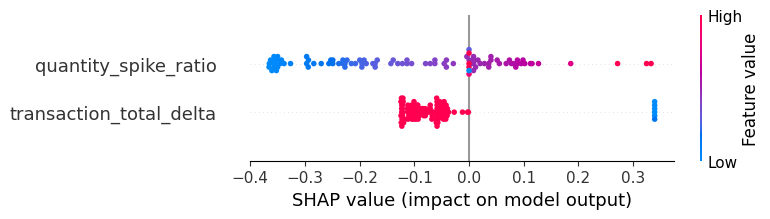

In [47]:
import shap
import numpy as np

background = X_train_resampled[:100]
explainer = shap.DeepExplainer(model, background)

X_test_np = X_test[:100].values
raw_shap_values = explainer.shap_values(X_test_np)

if isinstance(raw_shap_values, list):
    squeezed_shap_values = np.squeeze(raw_shap_values[0])
else:
    squeezed_shap_values = np.squeeze(raw_shap_values)

squeezed_features = X_test_np

shap.summary_plot(squeezed_shap_values, squeezed_features, feature_names=feature_cols)

# Inferences

In [48]:
if model is None:
  if not os.path.exists(MODEL_PATH):
    print(f'Model not found at {MODEL_PATH}, please run the cells start from Variables Initialization to the Saving Model')
  else:
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f'Model loaded from {MODEL_PATH}')

In [49]:
import random
import pandas as pd

def generate_inference_data(num_records=100, fraud_rate=0.15):
    """
    Generates a randomized dictionary of transaction data.
    """
    data = {
        'merchant_category': [],
        'payment_method': [],
        'region': [],
        'quantity_spike_ratio': [],
        'transaction_total_delta': [],
        'is_fraud': []
    }

    for _ in range(num_records):
        is_fraud = 1 if random.random() < fraud_rate else 0

        # Randomize basic categorical features
        data['merchant_category'].append(random.randint(1, 5))
        data['payment_method'].append(random.randint(1, 4))
        data['region'].append(random.randint(1, 5))
        data['is_fraud'].append(is_fraud)

        if is_fraud:
            data['quantity_spike_ratio'].append(round(random.uniform(1.9, 1000_000), 1))
            data['transaction_total_delta'].append(random.randint(-1000_000,-1))
        else:
            data['quantity_spike_ratio'].append(round(random.uniform(0, 1.9), 1))
            data['transaction_total_delta'].append(random.randint(0,1))
    return data

In [50]:
inference_data = generate_inference_data(num_records=1000, fraud_rate=0.20)
inference_df = pd.DataFrame(inference_data)
y_inference = inference_df['is_fraud']
X_inference = inference_df[feature_cols]

In [51]:
y_inference = y_inference.to_numpy().astype('float32')
y_inference

array([1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1.,
       0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
       1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 1., 0.

## Machine Learning Inference

In [52]:
dt_y_inference_pred = dt_model.predict(X_inference)

In [53]:
dt_y_inference_pred = dt_y_inference_pred.flatten()
dt_y_inference_pred

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,

### Classification Report

In [54]:
print("Classification Report:")
print(classification_report(y_inference, dt_y_inference_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       780
         1.0       1.00      1.00      1.00       220

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



### Confusion Matrix

In [55]:
print("Confusion Matrix:")
confusion_matrix(y_inference, dt_y_inference_pred)

Confusion Matrix:


array([[780,   0],
       [  0, 220]])

### Accuracy

In [56]:
print("Accuracy:")
accuracy_score(y_inference, dt_y_inference_pred)

Accuracy:


1.0

### AUC-ROC (Area Under Curve &  Receiver Operating Characteristic Curve)

In [57]:
print("AUC-ROC:")
roc_auc_score(y_inference, dt_y_inference_pred)

AUC-ROC:


np.float64(1.0)

## Deep Learning Inference

In [58]:
X_scaled_inference = scaler.transform(X_inference)

In [59]:
deepl_y_prediction_prob = model.predict(X_scaled_inference)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [60]:
deepl_y_prediction_pred = (deepl_y_prediction_prob > THRESHOLD).astype('int32')
deepl_y_prediction_pred = deepl_y_prediction_pred.flatten()
deepl_y_prediction_pred

array([1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,

### Classification Report

In [61]:
print("Classification Report:")
print(classification_report(y_inference, deepl_y_prediction_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       780
         1.0       1.00      1.00      1.00       220

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



### Confusion Matrix

In [62]:
print("Classification Report:")
confusion_matrix(y_inference, deepl_y_prediction_pred)

Classification Report:


array([[780,   0],
       [  0, 220]])

### Accuracy

In [63]:
print("Accuracy:")
accuracy_score(y_inference, deepl_y_prediction_pred)

Accuracy:


1.0

### AUC-ROC (Area Under Curve &  Receiver Operating Characteristic Curve)

In [64]:
print("AUC-ROC:")
roc_auc_score(y_inference, deepl_y_prediction_pred)

AUC-ROC:


np.float64(1.0)